# Restaurant demand forecasting — Layer 1 prototype

Goal: predict daily units sold **per menu item**, which is the foundation for:
- the sales forecast dashboard (aggregate this across items)
- the ingredient demand forecast (multiply this by the recipe/BOM table)

This notebook uses **synthetic data** so you can validate the whole pipeline
before wiring it into the FastAPI service. Swap `daily_item_sales.csv` for
real (or POS-exported) data later — nothing else below needs to change.

In [1]:
import pandas as pd 
from sqlalchemy import create_engine
import numpy as np

In [2]:
import datetime

In [3]:
USER = 'postgres'
PASSWORD = 'Anyasam101'
HOST = 'Localhost'
PORT = '5432'
DB_NAME = 'MONGA'

connection_string = f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}"
engine = create_engine(connection_string)

query = """
SELECT 
    c.calendar_date,
    o.store_id,
    mi.item_id,
    mi.category,
    mi.item_name,
    COALESCE(SUM(oi.quantity), 0) AS quantity
FROM calendar_dim c
CROSS JOIN menu_items mi
LEFT JOIN orders o ON o.order_timestamp::date = c.calendar_date
LEFT JOIN order_items oi ON oi.order_id = o.order_id AND oi.item_id = mi.item_id
GROUP BY c.calendar_date, o.store_id, mi.item_id, mi.item_name
ORDER BY mi.item_id, c.calendar_date;
"""

In [ ]:
try:
    df = pd.read_sql(query, con=engine)
    print(f"Successfully loaded {len(df)} rows.")

    # index=False prevents pandas from writing a row-number column into the CSV
    output_file = "data/extracted_data.csv"
    df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Data successfully saved to {output_file}")
except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # 6. Dispose of the engine connection pool
    engine.dispose()

Successfully loaded 354564 rows.
Data successfully saved to extracted_data.csv


In [9]:
items = df[~df['item_id'].str.contains('M')][['item_id', 'item_name']]
item_ids = items.drop_duplicates(subset=['item_id'], keep='first')

item_dict = df.set_index('item_name')['item_id'].to_dict()

def id_correction(row):
    return item_dict[row['item_name']]

df['item_id'] = df.apply(id_correction, axis=1)

df.to_csv('data/cleaned_extracted_data.csv', index=False)

### Engineering features


In [5]:
# Convert to datetime
df['calendar_date'] = pd.to_datetime(df['calendar_date'])
df['date'] = df['calendar_date'].dt.date
# Group by item to create time-series window features
grouped = df.groupby(['store_id', 'item_id'])['quantity']

df['lag_1'] = grouped.shift(1)
df['lag_7'] = grouped.shift(7).fillna(0)
df['lag_14'] = grouped.shift(14).fillna(0)
df['rolling_mean_7'] = grouped.transform(lambda x: x.rolling(7, min_periods=1).mean()).round(2)

# Date Features
df['day_of_week'] = df['calendar_date'].dt.dayofweek + 1  # 1=Mon, 7=Sun (ISODOW)
df['month'] = df['calendar_date'].dt.month
df['is_weekend'] = df['calendar_date'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_payday'] = df['calendar_date'].dt.day.isin([15, 30, 31]).astype(int)

df = df.replace(np.nan, 0)
df.head()

,calendar_date,store_id,item_id,category,item_name,quantity,date,lag_1,lag_7,lag_14,rolling_mean_7,day_of_week,month,is_weekend,is_payday
0,2022-01-01,STR_02,M000000001,Signature Chicken,The King,2,2022-01-01,0.0,0.0,0.0,2.0,6,1,1,0
1,2022-01-01,STR_01,M000000001,Signature Chicken,The King,4,2022-01-01,0.0,0.0,0.0,4.0,6,1,1,0
2,2022-01-01,STR_03,M000000001,Signature Chicken,The King,3,2022-01-01,0.0,0.0,0.0,3.0,6,1,1,0
3,2022-01-02,STR_03,M000000001,Signature Chicken,The King,1,2022-01-02,3.0,0.0,0.0,2.0,7,1,1,0
4,2022-01-02,STR_02,M000000001,Signature Chicken,The King,2,2022-01-02,2.0,0.0,0.0,2.0,7,1,1,0


### I realized seedfast created duplicate items with different ids, so I'll now try to map every item with the corresponing proper id 'SKU-x'

### Training the lightgbm model

In [6]:
import lightgbm as lgb

cutoff_date = datetime.date(2026, 7, 1)
df["item_id"] = df["item_id"].astype("category")
df["store_id"] = df["store_id"].astype("category")
df["category"] = df["category"].astype("category")

FEATURES = ["item_id", "store_id", "category", "day_of_week", "is_weekend", "month",
            "lag_1", "lag_7", "lag_14", "rolling_mean_7", "is_payday"]
TARGET = "quantity"

cutoff_date = df["date"].max() - pd.Timedelta(days=21)
train = df[df["date"] <= cutoff_date]
test = df[df["date"] > cutoff_date].copy()

train_set = lgb.Dataset(train[FEATURES], label=train[TARGET], categorical_feature=["item_id", "store_id", "category"])
params = {"objective": "regression", "metric": "mae", "learning_rate": 0.05, "num_leaves": 31, "verbose": -1}
model = lgb.train(params, train_set, num_boost_round=300)

### Evaluation

In [7]:
from sklearn.metrics import mean_absolute_error

test["predicted"] = model.predict(test[FEATURES]).clip(min=0)

overall_mae = mean_absolute_error(test[TARGET], test["predicted"])
overall_mape = (np.abs(test[TARGET] - test["predicted"]) / test[TARGET].replace(0, np.nan)).mean() * 100
print(f"Overall MAE:  {overall_mae:.2f} units/day")
print(f"Overall MAPE: {overall_mape:.1f}%")

per_item = (test.groupby("item_name")
            .apply(lambda g: (np.abs(g[TARGET] - g['predicted']) / g[TARGET].replace(0, np.nan)).mean() * 100)
            .sort_values())
per_item.round(1)

Overall MAE:  0.98 units/day
Overall MAPE: 48.4%


item_name
Saver Meal A Junior                        36.3
Lychee Fruit Tea (M)                       37.6
Lychee Fruit Tea (L)                       39.1
Green Dragon Milk Tea (M)                  39.3
Monga Salad Ala Carte                      39.4
Oolong Sea Salt Foam (M)                   40.2
Saver Meal C Junior Chop & Pasta           40.9
Hot Chick                                  41.0
Saver Meal B (1 Chop & Fries)              41.0
Green Dragon Milk Tea (L)                  41.1
Fire Dragon Milk Tea (L)                   41.4
Soup                                       41.6
Orange Fruit Tea (L)                       42.1
Dark Choco Sea Salt Foam (M)               42.3
Saver Meal D (2 Crispy Chicken & Rice)     43.4
Bottled Water                              43.9
Chicken Nuggets Noodles                    44.6
Rice                                       44.8
Fire Dragon Milk Tea (M)                   45.2
Chicken Chops Congee                       45.3
Black Dragon Milk Tea (L)     

### Plot actual vs predicted

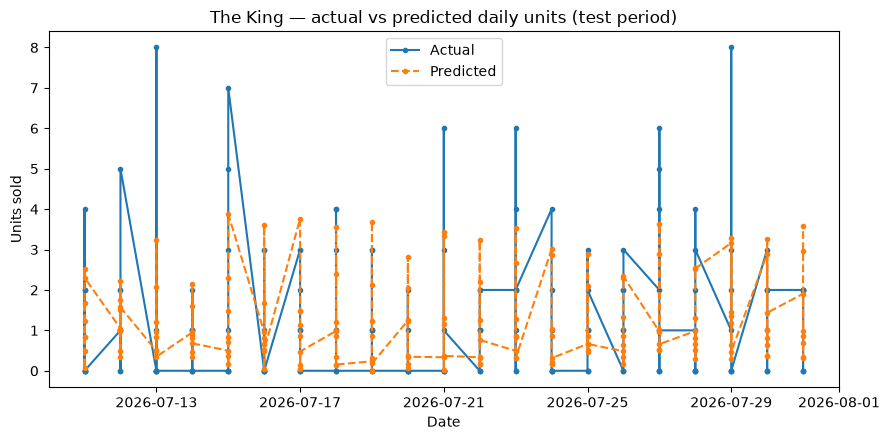

In [8]:
import matplotlib.pyplot as plt

item = "The King"  # try swapping this for any item_name in the menu
sub = test[test["item_name"] == item].sort_values("date")

plt.figure(figsize=(9, 4.5))
plt.plot(sub["date"], sub["quantity"], label="Actual", marker="o", markersize=3)
plt.plot(sub["date"], sub["predicted"], label="Predicted", linestyle="--", marker="o", markersize=3)
plt.title(f"{item} — actual vs predicted daily units (test period)")
plt.xlabel("Date"); plt.ylabel("Units sold"); plt.legend(); plt.tight_layout()
plt.show()

In [92]:
rn = 60
rm = rn + 5

actual_value = test.loc[test.index[rn:rm]]['quantity']
# # df.loc[0, FEATURES]
actual_value
predicted_value = model.predict(test.loc[test.index[rn:rm], FEATURES])
print(f'Actual Value: \n{actual_value}')
print(f'Predicted Value: {predicted_value}')

# test.loc[[test.index[0]], FEATURES]

Actual Value: 
5268    3
5269    2
5270    0
5271    2
5272    0
Name: quantity, dtype: int64
Predicted Value: [2.3346797  1.32065025 0.48357002 0.64776952 1.01511264]


## Notes / next steps

- **MAPE ~13% overall** on synthetic data — a reasonable baseline for a first pass.
- The model tracks **weekly seasonality** well but likely **misses holiday spikes**
  (Christmas Eve, New Year's) — because there's no holiday feature yet. Add an
  `is_holiday` binary column (a small hardcoded PH holiday calendar) and retrain
  to fix this — it's usually the single biggest accuracy win for a restaurant.
- Once this is solid: save the model (`model.save_model(...)`), and this whole
  notebook becomes the basis for the `models/` module inside the FastAPI service —
  the scheduled retraining job runs this same logic against real data.
- Layer 2 (recipe/BOM conversion) picks up right where `test["predicted"]` ends —
  that's the per-item forecast you'll multiply against ingredient quantities.